### Welcome to Trident: A Python Package for Whole-Slide Image Processing 


This tutorial will guide you step-by-step to process a single whole-slide image (WSI) using Trident:

- Tissue vs. background segmentation 
- Tissue coordinate extraction
- Tissue feature extraction


#### 0- Installation 


```
conda create -n "trident" python=3.10
conda activate trident
git clone git@github.com:mahmoodlab/trident.git && cd trident
pip install . -e

```

Please refer to the FAQ if you face installation issues.

#### 1- Tissue vs background segmentation

In [13]:
import os 
import torch 
from PIL import Image
import geopandas as gpd
from IPython.display import display
from huggingface_hub import snapshot_download

from trident import OpenSlideWSI
from trident.segmentation_models import segmentation_model_factory


In [23]:

# a. Download a WSI
OUTPUT_DIR = "tutorial-1/"
DEVICE = f"cuda:0" if torch.cuda.is_available() else "cpu"
WSI_FNAME = 'TCGA-AY-A8YK-01Z-00-DX1.89E3C546-0425-449B-A6FB-1C35168EA7EB.svs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
# local_wsi_dir = snapshot_download(
#     repo_id="MahmoodLab/unit-testing",
#     repo_type='dataset',
#     local_dir=os.path.join(OUTPUT_DIR, 'wsis'),
#     allow_patterns=[WSI_FNAME]
# )
local_wsi_dir = '../flat_wsis'
# b. Create OpenSlideWSI
wsi_path = os.path.join(local_wsi_dir, WSI_FNAME)


In [19]:
slide = OpenSlideWSI(slide_path=wsi_path, lazy_init=False)


In [20]:

# c. Run segmentation 
segmentation_model = segmentation_model_factory("otsu")


In [21]:
geojson_contours = slide.segment_tissue(segmentation_model=segmentation_model, target_mag=10, job_dir=OUTPUT_DIR, device=DEVICE)


C:\dev\projects\TRIDENT\trident\segmentation_models\model_zoo\otsu.py:49: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  otsu_masking = sk_morphology.remove_small_objects(otsu_masking, 60)
C:\dev\projects\TRIDENT\trident\segmentation_models\model_zoo\otsu.py:56: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  ot

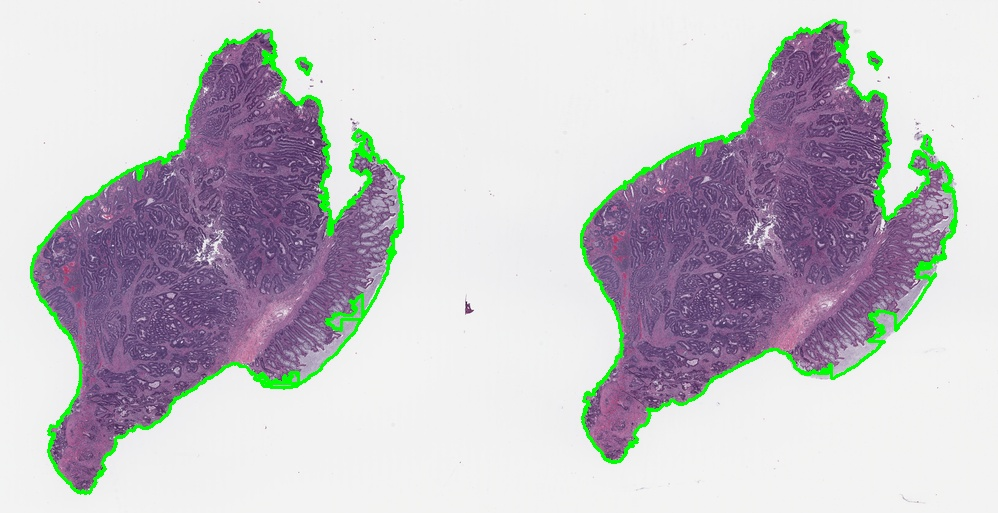

In [24]:

# d. Visualize contours
contour_image = Image.open(os.path.join(OUTPUT_DIR, 'contours', WSI_FNAME.replace('.svs', '.jpg')))
display(contour_image)


In [25]:

# e. Check contours saved into GeoJSON with GeoPandas
gdf = gpd.read_file(geojson_contours)
gdf.head(n=10)


,tissue_id,geometry
0,0,"POLYGON ((89991 13190.9, 89990.99 13190.9, 899..."
1,1,"POLYGON ((34527 13616, 34552 13641, 34527 1366..."
2,2,"POLYGON ((29131 5645.9, 29130.99 5645.9, 29130..."
3,3,"POLYGON ((84570 5095.9, 84569.99 5095.9, 84569..."
4,4,"POLYGON ((25233 2922.9, 25232.99 2922.9, 25232..."
5,5,"POLYGON ((80947 1997.9, 80946.99 1997.9, 80946..."


#### 2- Tissue coordinate extraction

We are patching the whole-slide image into non-overlapping patches of size 256x256 at 20x magnification (0.5 um/px).

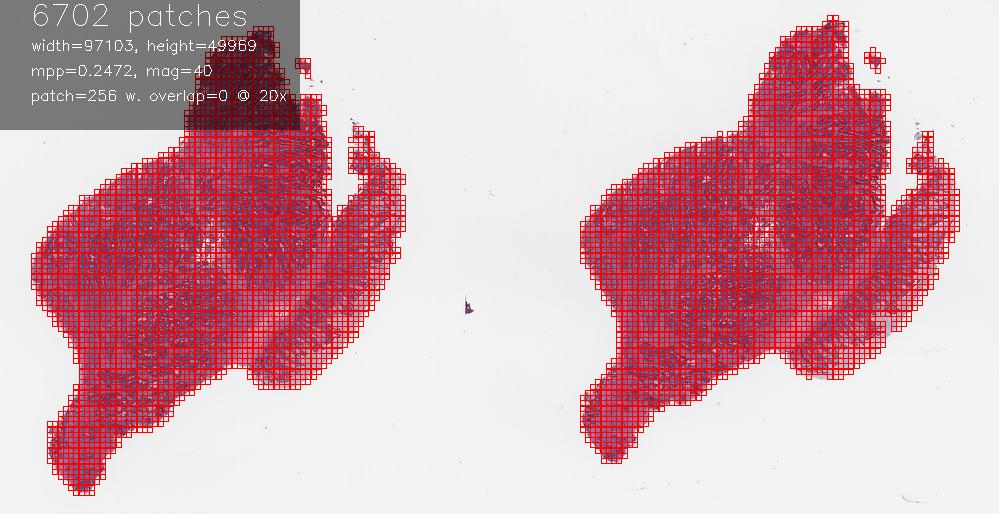

Contents and Attributes in patch coords file:
Object: coords
  Attribute - level0_height: 49969
  Attribute - level0_magnification: 40
  Attribute - level0_width: 97103
  Attribute - name: TCGA-AY-A8YK-01Z-00-DX1.89E3C546-0425-449B-A6FB-1C35168EA7EB
  Attribute - overlap: 0
  Attribute - patch_size: 256
  Attribute - patch_size_level0: 512
  Attribute - savetodir: tutorial-1/
  Attribute - target_magnification: 20


In [26]:
import h5py 

TARGET_MAG = 20
PATCH_SIZE = 256

# a. Run patch coordinate extraction
coords_path = slide.extract_tissue_coords(
    target_mag=TARGET_MAG,
    patch_size=PATCH_SIZE,
    save_coords=OUTPUT_DIR
)

# b. Visualize
viz_coords_path = slide.visualize_coords(
    coords_path=coords_path,
    save_patch_viz=os.path.join(OUTPUT_DIR, "visualization")
)
display(Image.open(viz_coords_path))

# c. Inspect h5 with patch coordinates 
def print_attrs(name, obj):
    print(f"Object: {name}")
    for key, value in obj.attrs.items():
        print(f"  Attribute - {key}: {value}")

with h5py.File(coords_path, 'r') as h5_file:
    print("Contents and Attributes in patch coords file:")
    h5_file.visititems(print_attrs)

#### 3- Patch feature extraction with the UNI model


In [10]:
from trident.patch_encoder_models import encoder_factory

PATCH_ENCODER = "uni_v2" # Visit the factory or check the README for a list of all available models

# a. Instantiate UNI model using the factory 
encoder = encoder_factory(PATCH_ENCODER)
encoder.eval()
encoder.to(DEVICE)

# b. Run UNI feature extraction
features_dir = os.path.join(OUTPUT_DIR, f"features_{PATCH_ENCODER}")
feats_path = slide.extract_patch_features(
    patch_encoder=encoder,
    coords_path=coords_path,
    save_features=features_dir,
    device=DEVICE
)

# c. Inspect h5 with patch features 
with h5py.File(feats_path, 'r') as h5_file:
    print("Contents and Attributes in feats file:")
    h5_file.visititems(print_attrs)


config.json:   0%|          | 0.00/587 [00:00<?, ?B/s]

c:\Users\301-18\anaconda3\envs\trident\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\301-18\.cache\huggingface\hub\models--MahmoodLab--UNI2-h. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP d

pytorch_model.bin:   0%|          | 0.00/2.73G [00:00<?, ?B/s]

C:\dev\projects\TRIDENT\trident\wsi_objects\WSI.py:921: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.autocast(device_type='cuda', dtype=precision, enabled=(precision != torch.float32)):


Contents and Attributes in feats file:
Object: coords
  Attribute - level0_height: 79104
  Attribute - level0_magnification: 40
  Attribute - level0_width: 66816
  Attribute - name: TCGA-AA-3939-01Z-00-DX1.6ceb6e8f-a469-4f42-9597-8bf853d95640
  Attribute - overlap: 0
  Attribute - patch_size: 256
  Attribute - patch_size_level0: 512
  Attribute - savetodir: tutorial-1/
  Attribute - target_magnification: 20
Object: features
  Attribute - encoder: uni_v2
  Attribute - name: TCGA-AA-3939-01Z-00-DX1.6ceb6e8f-a469-4f42-9597-8bf853d95640
  Attribute - savetodir: tutorial-1/features_uni_v2
